In [5]:
import pandas as pd
df = pd.read_csv("/content/zomato.csv")
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [6]:
print(df.columns.tolist())

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']


In [7]:
df.shape

(56252, 13)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [9]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [10]:
df.duplicated().sum()

np.int64(15703)

Removed 15,703 duplicate records to improve data quality and avoid biased analysis.

In [11]:
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (40549, 13)


In [12]:
df['rate'].unique()[:20]

array(['4.1/5', '3.8/5', '3.7/5', '3.6/5', '4.6/5', '4.0/5',
       '\\nTop floor', '4.2/5', '3.9/5', '3.1/5', '3.0/5', '3.2/5',
       '3.3/5', '2.8/5', " ('Rated 1.0'", " ('Rated 5.0'", '4.4/5',
       ' always a good experience',
       ' a mocktail and did i just hear unlimited desserts?!\\nGoodbye midweek blues!!!?\\n\\nI would specially mention the staff here-Chaitanya',
       '4.3/5'], dtype=object)

The dataset contained duplicate records, missing values, and incorrectly placed review text within rating and cost columns. Duplicates were removed, ratings were converted to numeric values, missing values were handled using median imputation, and unrealistic cost values were filtered out to improve data quality.

In [13]:
import numpy as np

df['rate'] = df['rate'].astype(str).str.extract(r'(\d+\.\d+)')

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['rate'].fillna(df['rate'].median(), inplace=True)

df['rate'].head()

/tmp/ipykernel_1469/3775166540.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rate'].fillna(df['rate'].median(), inplace=True)


,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [14]:
df['rate'].describe()

,rate
count,40549.000000
mean,3.732490
std,0.436522
min,0.500000
25%,3.500000
50%,3.800000
75%,4.000000
max,5.000000


In [15]:
df['approx_cost(for two people)'].head(10)

,approx_cost(for two people)
0,800
1,800
2,800
3,300
4,600
5,600
6,800
7,600
8,700
9,it turned out worse than the garlic bread. Th...


In [16]:
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.extract(r'(\d+)')
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .fillna(df['approx_cost(for two people)'].median())
)

df['approx_cost(for two people)'].describe()

,approx_cost(for two people)
count,4.054900e+04
mean,1.064473e+03
std,1.435741e+05
min,0.000000e+00
25%,2.000000e+02
50%,3.500000e+02
75%,5.000000e+02
max,2.891152e+07


In [17]:
df.sort_values('approx_cost(for two people)', ascending=False)[
    ['name', 'approx_cost(for two people)']
].head(20)

,name,approx_cost(for two people)
53994,specially the chicken mandiri tikka and the c...,28911524.0
25030,('Rated 3.0',2300.0
46938,'RATED\n I am a foodie and exploring differe...,2015.0
13330,('Rated 1.0',2014.0
5852,'RATED\n Overrated. Overpriced. I tried thei...,1983.0
24508,'RATED\n The pista roll rocks and the rasmal...,1200.0
28261,it being a small space,1000.0
17245,'RATED\n Visiting Hoot Was An Amazing Experi...,1000.0
43748,'RATED\n The black pearl one of the highest ...,1000.0
43723,having been to their outlet in Dubai,1000.0


In [18]:
df = df[df['approx_cost(for two people)'] <= 10000]

df['approx_cost(for two people)'].describe()

,approx_cost(for two people)
count,40548.000000
mean,351.479062
std,234.203495
min,0.000000
25%,200.000000
50%,350.000000
75%,500.000000
max,2300.000000


In [21]:
df['cuisines'].sample(20)


,cuisines
53822,"North Indian, South Indian, Chinese"
16398,"North Indian, Chinese, Mughlai, Kebab"
11850,"South Indian, North Indian, Chinese"
50560,Biryani
55999,"Chinese, North Indian"
39432,"Kerala, Konkan"
7840,"Fast Food, Burger"
32432,"Seafood, Biryani, South Indian, Chettinad, Chi..."
954,"Andhra, North Indian, Biryani"
23641,"Fast Food, Burger"


In [22]:
df = df[
    ~df['cuisines'].astype(str).str.contains(
        'RATED|Rated|This place|amazing|service',
        case=False,
        na=False
    )
]

In [23]:
df.shape


(38003, 13)

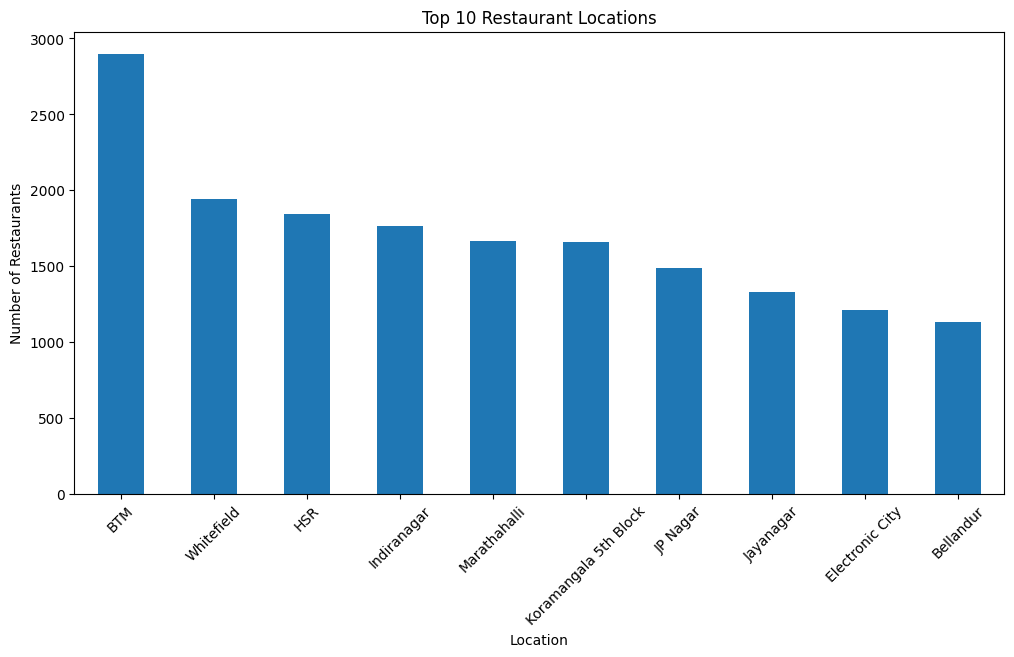

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df['location'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Restaurant Locations')
plt.xlabel('Location')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=45)
plt.show()

BTM emerged as the most popular restaurant location, followed by Whitefield and HSR. These locations represent major food and commercial hubs where customer demand is high. Businesses looking for partnerships or marketing campaigns should prioritize these areas.

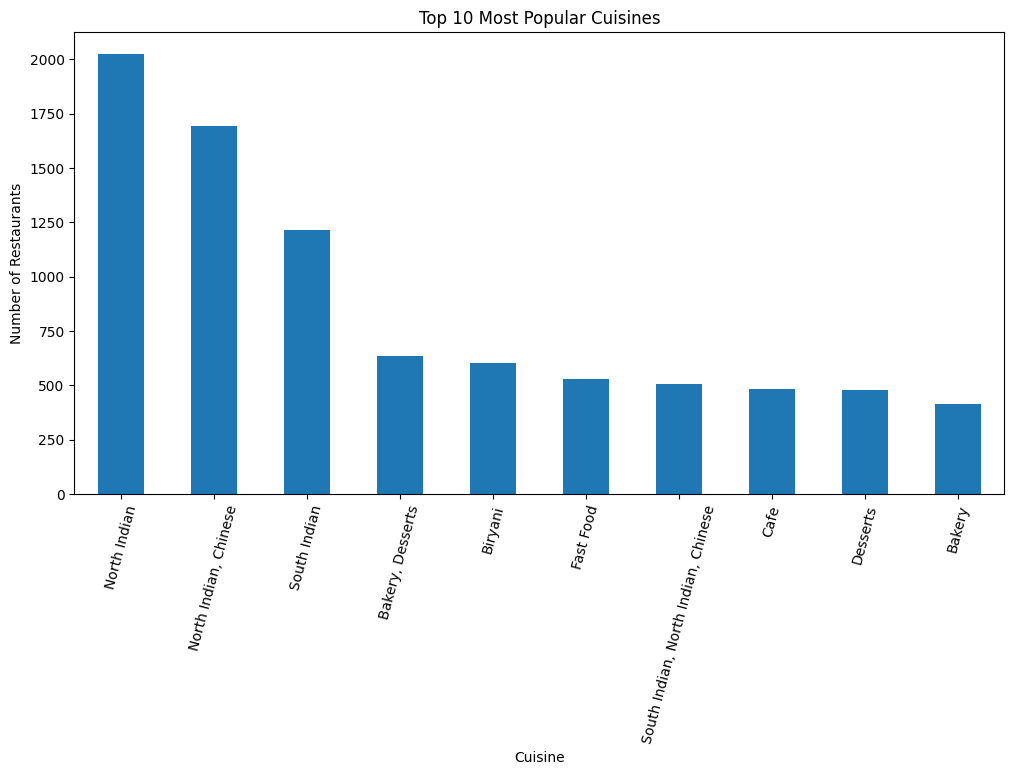

In [26]:
plt.figure(figsize=(12,6))

df['cuisines'].value_counts().head(10).plot(kind='bar')

plt.title('Top 10 Most Popular Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')

plt.xticks(rotation=75)
plt.show()

North Indian cuisine dominates the restaurant market, followed by combinations of North Indian and Chinese cuisines. South Indian cuisine and Biryani are also highly popular, indicating strong customer preference for traditional Indian food categories.

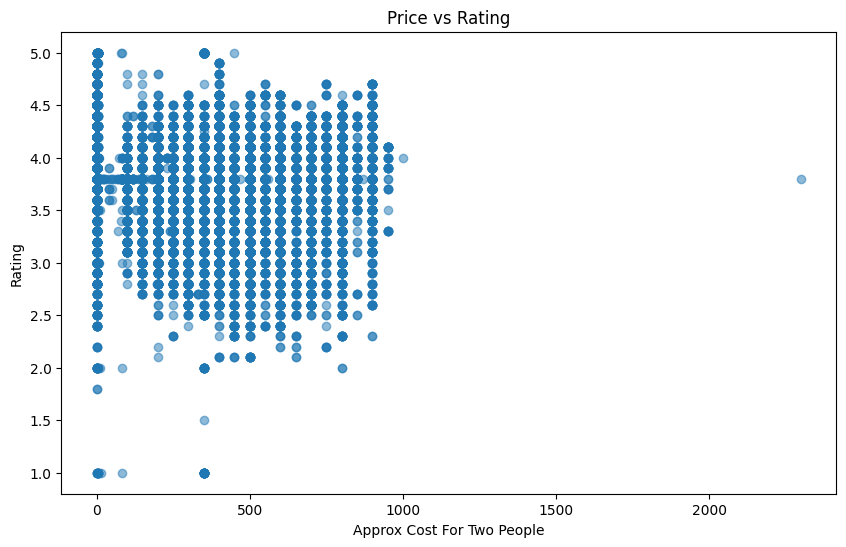

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['approx_cost(for two people)'],
    df['rate'],
    alpha=0.5
)

plt.title('Price vs Rating')
plt.xlabel('Approx Cost For Two People')
plt.ylabel('Rating')

plt.show()

The scatter plot shows that restaurant ratings are spread across all price ranges. Higher-priced restaurants do not always receive higher ratings, indicating that customer satisfaction depends on factors beyond price, such as food quality, service, and overall experience. Most restaurants are concentrated in the ₹100–₹1000 price range with ratings between 3.0 and 4.5.

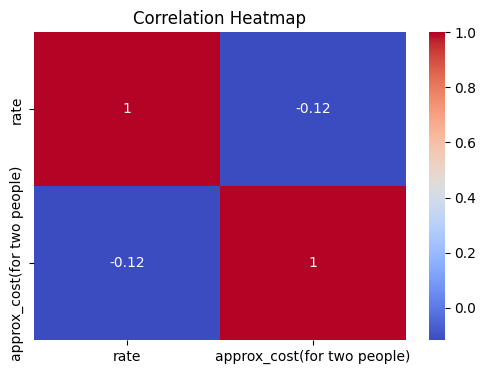

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['rate', 'approx_cost(for two people)']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap shows a very weak negative relationship (-0.12) between restaurant cost and rating. This indicates that higher-priced restaurants do not necessarily receive better ratings. Customer satisfaction appears to depend more on food quality, service, and overall experience than on pricing alone.

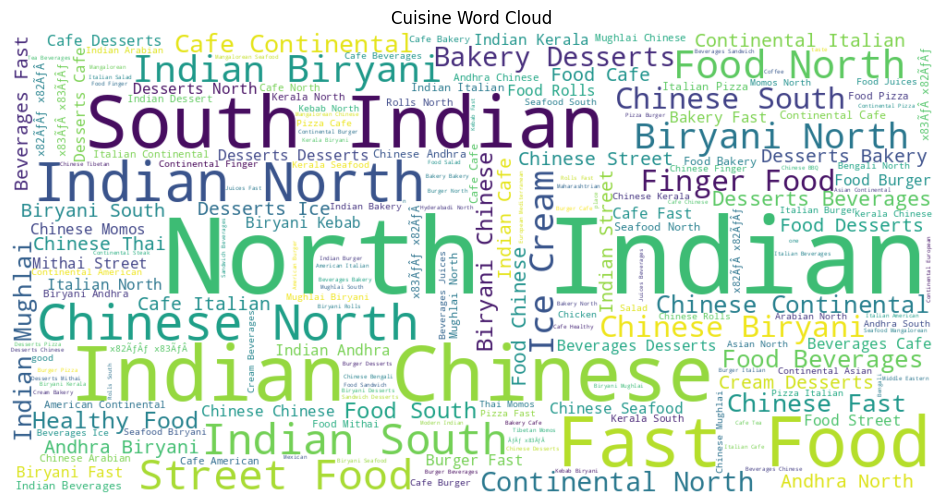

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cuisines'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Cuisine Word Cloud')
plt.show()

The word cloud highlights the most frequently occurring cuisines in the dataset. North Indian, Chinese, South Indian, Biryani, Fast Food, and Continental cuisines appear most prominently, indicating strong customer demand and market presence for these food categories.